# Assignment 2

**Assignment 2: Evolutionary Algorithms**

**Goal**: Implement an Evolutionary Algorithm to solve continuous and discrete problems.

**Note**: All assignments are individual, group work and/or the use of generative AI tools for completing the assignments in any capacity and/or copy paste from any resource are considered as plagiarism and reported.


* Part1: continuous problem that is concerned with finding minimum of functions, in this case, Sphere and Ackley
  functions.

* Part 2: discrete problem that is concerned with finding the solution for the N-queens problem. Could be defined as minimization or maximization.

For both parts, this assignment requires implementation of the main components of an evolutionary algorithm (i.e. *crossover*, *mutation*, *parent selection*, etc), and construction of your algorithm to solve given problems.

Please answer the `Questions` and implement coding `Tasks` by filling **PLEASE FILL IN** sections. *Documentation* of your code is also important. You can find the grading scheme in implementation cells.

**Setup**

**Install Prerequisites (Part 1 and 2)**

In [3]:
# Run this cell to install the required libraries
# %pip install numpy matplotlib scipy

**Imports (Part 1 and 2)**

In [4]:
import random

# Necessary libraries
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import ranksums

# Set seed
np.random.seed(42)

**Jupyter Notebook Magic (Part 1 and 2)**

In [5]:
# Enables inline matplotib graphs
%matplotlib inline

# Comment the line above and uncomment the lines below to have interactive plots
# WARN: may cause dependency issues
#%pip install PyQt5
#%matplotlib qt5
#plt.ion()

## Part 1: Continuous Optimization (5 points total)

In this part of the assignment you will implement an Evolutionary Algorithm to find the minimum of the following functions: [Sphere](https://www.sfu.ca/~ssurjano/spheref.html) and [Ackley](https://www.sfu.ca/~ssurjano/ackley.html) functions.


**Function Definitions \& Plotting**

**Sphere Function**


In [6]:
def Sphere(x):
    """source: https://www.sfu.ca/~ssurjano/spheref.html"""
    dimension = x.shape[0]
    return (1 / dimension) * (sum(x**2))

**Ackley Function**

In [7]:
def Ackley(x):
    """source: https://www.sfu.ca/~ssurjano/ackley.html"""

    # Ackley function parameters
    a = 20
    b = 0.2
    c = 2 * np.pi
    dimension = len(x)

    # Individual terms
    term1 = -a * np.exp(-b * np.sqrt(sum(x**2) / dimension))
    term2 = -np.exp(sum(np.cos(c * xi) for xi in x) / dimension)
    return term1 + term2 + a + np.exp(1)

**Plotting**

In [8]:
# Generate data for plotting
boundary_point, resolution = 5, 500
x = np.linspace(-boundary_point, boundary_point, resolution)
y = np.linspace(-boundary_point, boundary_point, resolution)

# Generate the coordinate points
X, Y = np.meshgrid(x, y)
positions = np.column_stack([X.ravel(), Y.ravel()])

# Get depths for all coordinate positions
z_unimodal = np.array(list(map(Sphere, positions))).reshape([resolution, resolution])
z_multimodal = np.array(list(map(Ackley, positions))).reshape([resolution, resolution])


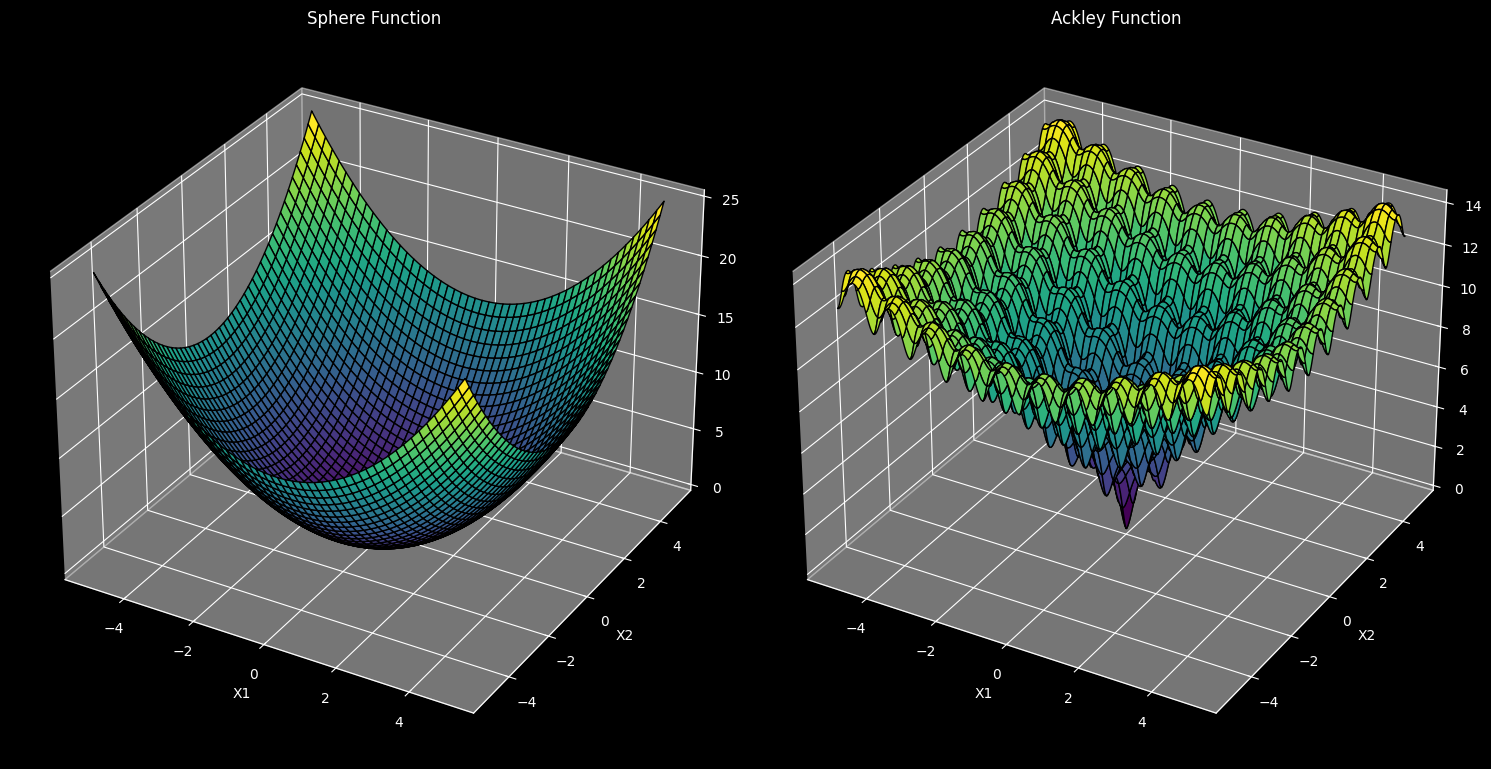

In [9]:
# Create 3D plot
fig = plt.figure(figsize=(15, 8))

titles = ["Sphere Function", "Ackley Function"]
for idx, z in enumerate([z_unimodal, z_multimodal]):
    # Create sub-plot
    ax = fig.add_subplot(121 + idx, projection="3d")

    # Plot the surface
    ax.plot_surface(X, Y, z, cmap="viridis", edgecolor="k")

    # Set labels
    ax.set_xlabel("X1")
    ax.set_ylabel("X2")
    ax.set_title(titles[idx])
    # ax.autoscale(True)

# Show the plot
plt.tight_layout()
plt.show()

---
**Question 1.1 (0-0.2 pt):** Looking at the Sphere and Ackley functions, please discuss the characteristics of these functions and compare their complexity in terms of local and global optima.

**Answer:**
The Sphere is a simple convex function with only one minimum, no local minima to get caught in. \
The Ackley function is a non-convex, odd shape with many local minima but a clear global minimum

---
**Question 1.2 (0-0.25-0.5 pt):** Please provide a pseudo-code for your evolutionary algorithm. Please try to be as formal as possible!

**Answer:**
```
# Parent Selection (Tournament size 3)
For each individual i in population:
    Randomly select 3 candidates
    Choose the one with lowest fitness


# Mutation (Random Resetting)
For each gene:
    With probability p_m
         replac gene with random value in [-50, 50]

# Binomial Crossover
For each individual:
    For each dimension j:
          if crossover hits
                take the mutated value
          else
                take the parent value
    make sure at least one mutated dimension with j_rand

# Evaluate offspring
f_offspring <- f(X_offspring)

# Survivor Selection
Combine parents and offspring
Keep mu individuals with lowest fitness

```

---
**Task 1.1: Implementation of Evolutionary Algrotihm (0-0.65-1.3-1.95-2.6 pt):** Implement an evolutionary algorithm and its components to find the minimum point of a function. Here, domain should be between [-50,50].

In [10]:
#################################
# Grading
# 0 pts if the code does not work, code works but it is fundamentally incorrect
# 0.65 pts if the code works but some functions are incorrect and it is badly explained
# 1.3 pts if the code works but some functions are incorrect but it is explained well
# 1.95 pts if the code works very well aligned with the task without any mistakes, but it is badly explained
# 2.6 pts if the code works very well aligned with the task without any mistakes, and it is well explained
################################################################
# variation
# selection
# inheritance

LOW, HIGH = -50, 50
seed = 42
rng = np.random.default_rng(seed)


#Initialize a population randomly based on the population size and dimensions
def initialization(population_size, num_dimensions):
    """
    Initialize the starting population with random individuals.
    Each gene of an individual corresponds to a point on a dimension in the function

    :param population_size: int
    :param num_dimensions: int
    :return: x matrix
    """

    ################################################################

    # if there is no RNG during initialization, then there will be no variation
    x = rng.uniform(LOW, HIGH, size=(population_size, num_dimensions))

    ################################################################

    return x #return population


# Implement the evaluation function that can evaluate all the solutions in a given population.
def evaluation(x, objective_function):
    """
    Evaluate the fitness of the population members

    :param x: matrix
    :param objective_function: Sphere/Ackley function
    :return fitness matrix
    """

    ################################################################

    # PLEASE FILL IN
    fitness = np.asarray(objective_function(x)).reshape(-1)  # f(x)

    ################################################################
    return fitness


# Implement the crossover operator by choosing a suitable method. For inspiration, take a look at the lecture slides
def crossover(x_parents, x_mutated, p_crossover):
    """
    Perform **Binomial** crossover to create offsprings.

    :param x_parents: matrix
    :param x_mutated: mutated parents matrix
    :param p_crossover: float
    :return: offspring matrix

    u_ij = { v_ij   if rand([0,1]) <= CR or j = randi([0,D])
             x_ij   else
    """

    ################################################################

    # PLEASE FILL IN
    N, D = x_parents.shape
    offspring = np.zeros((N, D))

    for i in range(N):                  # go through each population
        j_rand = rng.integers(0, D)     # j_rand to make sure there is always mutation
        for j in range(D):              # each dimension
            if rng.random() <= p_crossover or j == j_rand:  # if crossover rate is less than or equal to or j_rand
                offspring[i, j] = x_mutated[i, j]           # take mutated
            else:
                offspring[i, j] = x_parents[i, j]           # otherwise take the parents

    ################################################################
    return offspring


# Implement the crossover operator by choosing a suitable method. For inspiration, take a look at the lecture slides
def mutation(x, m_rate):
    """
    Apply mutation to an individual.

    :param x: list[ndarray[...]]
    :param m_rate: mutation_rate float
    :return: x_mutated list[ndarray[...]]

    Implemented Random Resetting mutation
    """

    ################################################################
    # PLEASE FILL IN
    mask = rng.random(x.shape) < m_rate  # condition: sample from shape as x where < F
    y = rng.uniform(LOW, HIGH, size=x.shape) # sample y in +-50 (integer) with same shape as x
    x_mutated = np.where(mask, y, x) # perturb x'

    ################################################################

    return x_mutated


def parent_selection(x, f):
    """
    Select parents for the next generation

    :param x: list[ndarray[...]]
    :param f: float
    :param population_size: int
    :return x_parents: (pop, dims)
    :return f_parents: (pop,)
    """

    ################################################################

    # PLEASE FILL IN
    N, D = x.shape
    parents_idx = np.empty(N, dtype=np.int64)
    size = f.shape[0]

    for i in range(N):
        cand = rng.integers(0, size, size=3)  # e.g. cand = [3, 7, 2]
        best = cand[np.argmin(f[cand])]             # grab best cand from the 3
        parents_idx[i] = best                       # add it to parents_idx ~ [3, 1, 2... population_size]

    ####################################

    return x[parents_idx], f[parents_idx]


def survivor_selection(x, f, x_offspring, f_offspring):
    """
    Select the survivors, for the population of the next generation

    :param x: (population_size, dimensions)
    :param f: (population_size, 1)
    :param x_offspring: matrix
    :param f_offspring: matrix
    :return x: matrix
    :return f: matrix
    """


    ################################################################

    # PLEASE FILL IN
    mu = x.shape[0]                     # mu
    x = np.vstack((x, x_offspring))     # VERTICALLY STACK to combine the offspring and current x
    f = np.concatenate((f, f_offspring))# join them on the same axis
    best_idx = np.argsort(f)[:mu]       # find the best_idx that minimize f with only mu results

    ################################################################
    return x[best_idx], f[best_idx]


def ea(
    # hyperparameters of the algorithm
    population_size,
    max_fit_evals,  # Maximum number of evaluations
    p_crossover,  # Probability of performing crossover operator
    m_rate,  # mutation rate
    dimensions,  # number of dimensions
    objective_function,  # objective function to be minimized
):
    # Calculate the maximum number of generations
    # Maximum number of function evaluations should be the same independent of the population size
    max_generations = int(max_fit_evals / population_size)  # DO NOT CHANGE



    ################################################################
    # PLEASE FILL IN

    # 1) Initialize population
    x = initialization(population_size, dimensions)

    # 2) Evaluate population fitness
    f = evaluation(x, objective_function)

    ################################################################

    # Find the best individual and append to a list to keep track in each generation
    idx = np.argmin(f)
    x_best = [x[idx]]
    f_best = [f[idx]]


    # Loop over the generations
    for _ in range(max_generations - 1):
        # Perform the EA steps

        ################################################################

        # PLEASE FILL IN

        # 1) Parent selection
        x_parents, f_parents = parent_selection(x, f)

        # 2) Mutation
        x_mutated = mutation(x_parents, m_rate)

        # 3) Crossover
        x_offspring = crossover(x_parents, x_mutated, p_crossover)

        # 4) Evaluate offspring
        f_offspring = evaluation(x_offspring, objective_function)

        # 5) Survivor selection (elitist μ+λ)
        x, f = survivor_selection(x, f, x_offspring, f_offspring)



        ################################################################

        # Find the best individual in current generation and add to the list
        idx = np.argmin(f)
        xi_best = x[idx]
        fi_best = f[idx]
        if fi_best < f_best[-1]:
            x_best.append(xi_best)
            f_best.append(fi_best)
        else:
            x_best.append(x_best[-1])
            f_best.append(f_best[-1])

    return x_best, f_best  # return the best solution and fitness in each generation

#### Check Your Implementation: Running The Evolutionary Algorithm

Run the cell below, if you implemented everything correctly, you should see
the algorithm running.

In [11]:
# Dummy parameters
kwargs = {
    "population_size": 20,
    "max_fit_evals": 1000,  # maximum number of fitness evaluations
    "p_crossover": 0.9,  # crossover probability
    "m_rate": 0.1,  # mutation rate
    "dimensions": 10,
    "objective_function": Sphere,
}

# Run the EA
x_best, f_best = ea(**kwargs)

# Print the best individual and its fitness
print("Best solution:", x_best[-1])
print("Best Fitness:", f_best[-1])

# Clear cache
del x_best, f_best, kwargs

Best solution: [ -4.42237102 -29.76366352 -19.40433758   7.92195689  41.26999907
  41.97774154  25.85195298  21.9462956   23.21281869  12.73088407]
Best Fitness: 172.47594404964312


**Reults and statistical analysis**

Remember that the EAs are sthocastic algorithms that can produce different results as a result of independent runs.

How do we find overal performance of the algorithm and compare the results?

By running multiple times and performing statitical tests. Therefore, you would need to run your algorithm **20 times** and plot the *average* results.

First, we would need to **defining some helper functions** for finding the average and standard deviations of multiple runs and ploting them. In the next few cells, we give you some pre-made functions for this purpose.

There is no work for you to do, but do look over them and get familiar with how they operate.

In [12]:
def calculate_mean_std(f_best):
    """This is a helper function to calculate the mean and standard deviation of the best fitness values."""
    f_best = np.array(f_best)
    avg = np.mean(f_best, axis=0)
    std = np.std(f_best, axis=0)
    return avg, std

In [42]:
def run_experiment(population_size, p_crossover, m_rate):
    runs = 20  # DO NOT CHANGE - number of runs
    max_fit_evals = 5000  # DO NOT CHANGE

    sphere10D = []
    sphere50D = []
    ackley10D = []
    ackley15D = []

    for _ in range(runs):
        _, f_best_sphere10D = ea(
            population_size[0],
            max_fit_evals,
            p_crossover[0],
            m_rate[0],
            10,
            Sphere,
        )
        _, f_best_sphere50D = ea(
            population_size[1],
            max_fit_evals,
            p_crossover[1],
            m_rate[1],
            50,
            Sphere,
        )
        _, f_best_ackley10D = ea(
            population_size[2],
            max_fit_evals,
            p_crossover[2],
            m_rate[2],
            10,
            Ackley,
        )
        _, f_best_ackley15D = ea(
            population_size[3],
            max_fit_evals,
            p_crossover[3],
            m_rate[3],
            15,
            Ackley,
        )

        sphere10D.append(f_best_sphere10D)
        sphere50D.append(f_best_sphere50D)
        ackley10D.append(f_best_ackley10D)
        ackley15D.append(f_best_ackley15D)

    # find average and std of the runs
    sphere10D_avg, sphere10D_std = calculate_mean_std(sphere10D)
    sphere50D_avg, sphere50D_std = calculate_mean_std(sphere50D)
    ackley10D_avg, ackley10D_std = calculate_mean_std(ackley10D)
    ackley15D_avg, ackley15D_std = calculate_mean_std(ackley15D)

    avgs = [sphere10D_avg, sphere50D_avg, ackley10D_avg, ackley15D_avg]
    stds = [sphere10D_std, sphere50D_std, ackley10D_std, ackley15D_std]
    all_runs = [
        sphere10D,
        sphere50D,
        ackley10D,
        ackley15D,
    ]

    return avgs, stds, all_runs

In [43]:
def generate_subplot_function(
    avgs_experiment_1,
    stds_experiment_1,
    labels,
    avgs_experiment_2,
    stds_experiment_2,
    n_columns,
    n_queens,
):
    """This helper function generates subplots for the experiments."""
    fig, axes = plt.subplots(nrows=1, ncols=n_columns, figsize=(18, 6))

    for i in range(len(avgs_experiment_1)):
        if avgs_experiment_2 is not None:
            # Plot data for subplot 1
            axes[i].plot(avgs_experiment_2[i], label="Experiment 2", color="green")
            axes[i].fill_between(
                np.arange(len(avgs_experiment_2[i])),
                avgs_experiment_2[i] - stds_experiment_2[i],
                avgs_experiment_2[i] + stds_experiment_2[i],
                alpha=0.2,
                color="green",
            )
            axes[i].set_ylim(bottom=0)

            if n_queens:
                axes[i].set_ylim(top=n_queens[i])

        axes[i].plot(avgs_experiment_1[i], label="Experiment 1", color="blue")
        axes[i].fill_between(
            np.arange(len(avgs_experiment_1[i])),
            avgs_experiment_1[i] - stds_experiment_1[i],
            avgs_experiment_1[i] + stds_experiment_1[i],
            alpha=0.2,
            color="blue",
        )
        axes[i].set_title(labels[i])
        axes[i].set_ylim(bottom=0)
        if n_queens:
            axes[i].set_ylim(top=n_queens[i])

    # Set common labels and title
    for ax in axes:
        ax.set_xlabel("Generations")
        ax.set_ylabel("Average Best Fitness")
        ax.legend()

    plt.tight_layout()

#### Running The Experiments

In the following cell we run the EA over several different hyper-parameter values.

In [44]:
population_size = [50, 50, 50, 50]  # DO NOT CHANGE
p_crossover = [0.8, 0.8, 0.8, 0.8]  # DO NOT CHANGE
m_rate = [0.1, 0.1, 0.1, 0.1]  # DO NOT CHANGE

avgs_experiment_1, stds_experiment_1, all_runs_experiment_1 = run_experiment(
    population_size, p_crossover, m_rate
)

#### Plotting The Results

In the following cell we plot the results of the experiments.

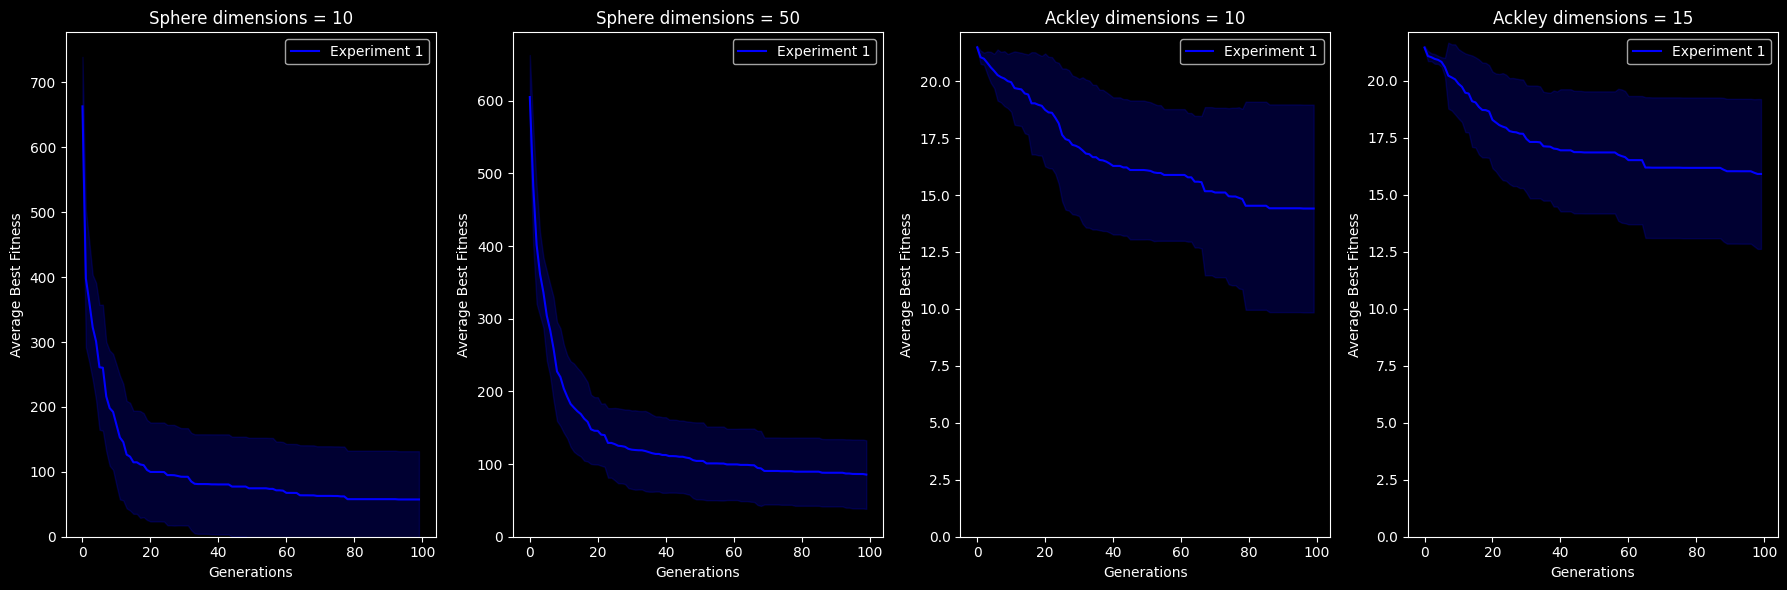

In [45]:
labels = [  # DO NOT CHANGE
    "Sphere dimensions = 10",
    "Sphere dimensions = 50",
    "Ackley dimensions = 10",
    "Ackley dimensions = 15",
]

generate_subplot_function(
    avgs_experiment_1,
    stds_experiment_1,
    labels,
    avgs_experiment_2=None,
    stds_experiment_2=None,
    n_columns=4,
    n_queens=None,
)

---

**Question 1.3 (0-0.25-0.5 pt):** Describe the results that you see in the line graphs. How is the performance of the EA on Sphere and Ackley functions? How the results are different between functions and dimensions? What causes these differences?

**Answer:** PLEASE FILL IN

---
**Improve Your Results**

Experiment with the hyperparameters of the algorithm and find a set of parameters that can perform better than the previous results. Compare the results using statistical test and find a settings where there is a statistically significant improvement.

You can adjust the *population size*, *crossover probability* and *mutation rate* to find the settings that can work statistically better relative to the previous results. Please look at the "ADJUST THESE VALUES" part to experiment and improve your solutions.

Optionally, you can also improve your algorithm by implementing/changing strategies used

In [46]:
# Grading (bonus points):
# 0.4 pts bonus for the optional improvement: if you implement different strategy, it works and produces significantly better results
# Different strategy could be a different implementation of the mutation/crossover/parent or survival selection mechanisms


# Implement your strategy here and integrate with the Evolutionary Algorithm
# PLEASE FILL IN

##################

In [127]:
################################################################

population_size = [  # ADJUST THESE VALUES
    50,
    50,
    50,
    50,
]
p_crossover = [  # ADJUST THESE VALUES
    0.9,
    0.8,
    0.65,
    0.8,
]
m_rate = [  # ADJUST THES# E VALUES
    0.1,
    0.03,
    0.01,
    0.02,
]


# raise NotImplementedError
# Remove the line above once you've made the changes you want

################################################################

**Running the experiment again**

In [136]:
avgs_experiment_2, stds_experiment_2, all_runs_experiment_2 = run_experiment(
    population_size, p_crossover, m_rate
)

**Plotting the new and previous results**

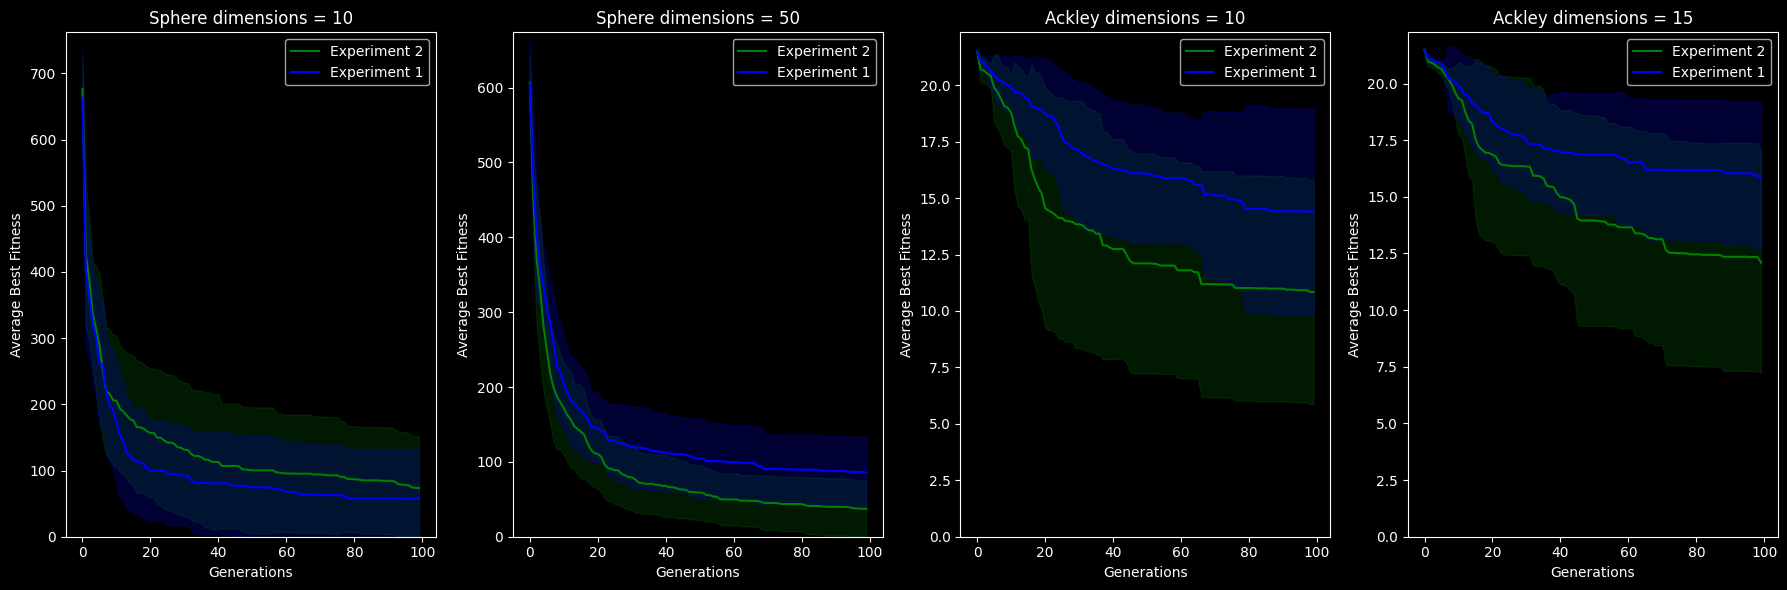

In [137]:
labels = [
    "Sphere dimensions = 10",
    "Sphere dimensions = 50",
    "Ackley dimensions = 10",
    "Ackley dimensions = 15",
]  # DO NOT CHANGE

generate_subplot_function(
    avgs_experiment_1,
    stds_experiment_1,
    labels,
    avgs_experiment_2=avgs_experiment_2,
    stds_experiment_2=stds_experiment_2,
    n_columns=4,
    n_queens=None,
)

**Measuring the statistical significance of differences of two sets of experiment results**

The final step is to calculate whether the results from your set of hyperparameters (experiment 2) resulted in significantly better results.

To do this, we will perform a statistical test know as [rank-sum test](https://www.wikiwand.com/en/Mann%E2%80%93Whitney_U_test).

You will calculate the rank-sum for the results of the first and second experiments.

In [138]:
alpha = 0.05

# this loops over the 4 different functions we have
#   (Sphere dimensions = 10, Sphere dimensions =50, Ackley dimensions = 10, Ackley dimensions = 15)
labels = [
    "Sphere function 10 dimensions:",
    "Sphere function 50 dimensions:",
    "Ackley function 10 dimensions:",
    "Ackley function 15 dimensions:",
]
for i in range(4):
    runs_exp_1 = all_runs_experiment_1[i]
    runs_exp_2 = all_runs_experiment_2[i]

    best_per_run_exp_1 = [sublist[-1] for sublist in runs_exp_1]
    best_per_run_exp_2 = [sublist[-1] for sublist in runs_exp_2]

    t_statistic, p_value = ranksums(best_per_run_exp_1, best_per_run_exp_2)
    if p_value < alpha:
        # if np.mean(best_per_run_exp_1) < np.mean(best_per_run_exp_2):
        print(
            labels[i],
            "Experiment 1 average:",
            np.mean(best_per_run_exp_1),
            ", Experiment 2 average:",
            np.mean(best_per_run_exp_2),
            ",significant difference.",
        )
        # else:
        #    print(labels[i], "significant difference. Experiment 2 is better.")
    else:
        # if np.mean(best_per_run_exp_1) < np.mean(best_per_run_exp_2):
        print(
            labels[i],
            "Experiment 1 average:",
            np.mean(best_per_run_exp_1),
            ", Experiment 2 average:",
            np.mean(best_per_run_exp_2),
            ",no significant difference.",
        )
        # else:
        #    print(labels[i], "no significant difference. Experiment 2 is better.")

Sphere function 10 dimensions: Experiment 1 average: 57.42100318380942 , Experiment 2 average: 73.55594503969897 ,no significant difference.
Sphere function 50 dimensions: Experiment 1 average: 85.52280407152695 , Experiment 2 average: 37.33296071792063 ,significant difference.
Ackley function 10 dimensions: Experiment 1 average: 14.40863440781649 , Experiment 2 average: 10.840072373530877 ,significant difference.
Ackley function 15 dimensions: Experiment 1 average: 15.920086826505383 , Experiment 2 average: 12.100589197582718 ,significant difference.


---
**Question 1.4 (0-0.3-0.6-0.9-1.2 pt):** Please improve the results significantly in each case (i.e. on Sphere and Ackley functions with 10, 50 and 10, 15 dimensions respectively) and discuss what kinds of changes you had to do to achieve this improvement. Please provide your reasoning why the new parameter settings worked better.

1. Increasing Population Size \
A larger population improves diversity and allows better exploration of the search space.
This was especially important for Sphere 50D because of the higher dimensional space and Ackley because of the local minima. With more individuals, the algorithm was less likely to converge prematurely.

2. Adjusting Mutation Rate \
Originally, the mutation rate was too high, which caused excessive randomness and prevented convergence.
Reducing it allowed for better fine-tuning near the minimum which was important for Sphere and less disruption of promising individuals

3. Increasing Crossover Probability \
Higher crossover probability improved exploitation by combining good solutions more effectively. This was particularly useful for Ackley, where combining partial good solutions helped escape local minima.

Grading:

0 pts: No answer or non of the cases were improved.

0.3 pts: At least one of the cases improved significantly but reasons why were not clearly explained.

0.6 pts: One or two cases improved significantly and the reasons why were somewhat clear.

0.9 pts: Three to four cases improved significanlty and the reasons why are clear.

1.2 pts: All of the cases improved significanlty and the reasons why are clear.


**Answer:** PLEASE FILL IN


---
## Part 2: Discrete Optimization (The N-Queens Problem, 5 points total)

Implement an Evolutionary Algorithm for the **n-queens problem**.
Below is a visualization of a solution for the n-queens problem when n = 4. Observe that none of the queens are attacking each other.

We would like to implement an EA that can find a solution for any given N by N board but in this case it is required to place N queens where none of them attack each other.

You may use the implementation of the EA you used for solving continuous problems in Part 1. But remember, this is a discere problem so you would need to think about how to represent the solutions and search using the evolutionary operators.

Consider, what changes you would need to do!


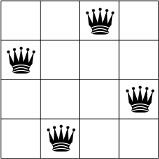


It is usually better to start simple and generalize your implementation. So, let's start with the case when **N = 4**.

**Question 2.1 (0-0.3 pt):** How do you represent a solution (a 4 queen placement on a 4x4 chess board)? In particular, specify the length of your genotype representation, what each gene (dimension) represents, and what values they can get.

**Answer:** To represent a solution, each permutation must have exactly one queen per column, exactly one queen per row and no diagonal conflicts and there must be exactly n queens on the board.

**Question 2.2 (0-0.2 pt)**: Please write down an example representation and discuss what it means.

**Answer:** A solution could be represented like [2, 0, 3, 1] where the indexs are the columns and the values are the rows. so to represent in x, y format this set would be (0, 2), (1, 0), (2, 3), (3, 1)

**Question 2.3 (0-0.2 pt):** How many possible solutions can be generated in your representation?

**Answer:** In a 4x4 grid, I believe there are 2 solutions but the amount of solutions are not linear or exponential.

---
**Task 2.1 (0-0.20-0.40-0.80):** Implementation of solution encoding, visualization and evaluation functions.

In [22]:
################################################################


# PLEASE FILL IN - how do you represent your solution?
example_solution = np.asarray([2, 0, 3, 1])

################################################################

Write a function below that can visualize your solution. For instance, the output may look like below, a matrix representing the 4x4 chess board where each Q indicates a queen placement and dots are empty cells.


![image.png](attachment:ef1059d6-48a4-4e38-b902-323f3d61a745.png)

In [23]:
def visualize_solution(solution):
    """Visualize the placement of queens on the chessboard."""

    ################################################################

    # PLEASE FILL IN
    n = solution.shape[0]
    board = [["Q" if j == solution[i] else "•" for j in range(n)] for i in range(n)]

    for i in range(n):
        for j in range(n):
            print(f"{board[i][j]} ", end="")
        print()


    ################################################################

Write the evaluation function to assess how good your solution is.

In [24]:
def evaluate_solution_n_queens(solution):
    """Calculate the fitness of an solution."""
    ################################################################

    # PLEASE FILL IN

    fitness = 0
    n = solution.shape[0]

    for i in range(n):
        for j in range(n):
            if abs(solution[i] - solution[j]) == abs(i - j) and i != j:
                fitness += 1
            if solution[i] == solution[j] and i != j:
                fitness += 1

    ################################################################

    return fitness

Try your implementations to see if your solution encoding matches to visualization and whether the fitness is computed correctly.

In [25]:
#################################
# Grading
# 0 pts: No attempt, representation discussed does not match with the implementation and visualization, fitness is not correct.
# 0.20 : Solution representation matches with visualization, fitness computation is not correct, no explanation in the code.
# 0.50 : Solution representation matches with visualization, fitness computation is correct, no explanation in the code.
# 0.80 : Solution representation matches with visualization, fitness computation is correct, the implementation explained well.
################################################################


###################### DO NOT CHANGE #########################
print("Genotype (solution representation):", example_solution)
print("Phenotype (solution visualization):")
visualize_solution(example_solution)
print("Solution fitness", evaluate_solution_n_queens(example_solution))
###################### DO NOT CHANGE #########################

Genotype (solution representation): [2 0 3 1]
Phenotype (solution visualization):
• • Q • 
Q • • • 
• • • Q 
• Q • • 
Solution fitness 0


---

**Task 2.2 (0-0.4-0.8-1.2-1.6 pt):** Write an evolutionary algorithm that can initialize a population of solutions and finds N queen placement to NxN board optimizing the number of attacks (could be minimization or maximization based on your evaluation function of the solutions).

In [26]:
#################################
# Grading
# 0 pts if the code does not work, code works but it is fundamentally incorrect
# 0.4 pts if the code works but some functions are incorrect and it is badly explained
# 0.8 pts if the code works but some functions are incorrect but it is explained well
# 1.2 pts if the code works very well aligned with the task without any mistakes, but it is badly explained
# 1.6 pts if the code works very well aligned with the task without any mistakes, and it is well explained
################################################################


#initialize a population of solutions for the N queens problem where num_dims = N
def initialization_n_queens(population_size, num_of_dims):
    """Generate a population of solutions."""
    ################################################################

    # PLEASE FILL IN
    x = np.zeros((population_size, num_of_dims))
    base = np.arange(num_of_dims, dtype=np.int64)
    for i in range(population_size):
        x[i] = base.copy()
        rng.shuffle(x[i])
    ################################################################

    return x #return population


def evaluation_n_queens(x):
    """Evaluate the whole population and return the fitness of each."""
    return np.asarray([evaluate_solution_n_queens(solution) for solution in x])


def crossover_n_queens(x_parents, p_crossover):
    """Perform **uniform** crossover to create offsprings."""

    ################################################################

    # PLEASE FILL IN
    num_parents, n = x_parents.shape
    offspring = np.zeros((num_parents, n), dtype=x_parents.dtype)


    for i in range(0, num_parents, 2):      # iterate 2 at a time
        parent1 = x_parents[i]              # initialize parent 1 and 2 and children as their parents
        parent2 = x_parents[i + 1]
        child1 = parent1.copy()
        child2 = parent2.copy()

        if rng.random() <= p_crossover:     # crossover or no?
            idxs = rng.choice(n, size=n//2, replace=False)         # of the length of the solution, choose half of the indexes to change


            for k in range(len(idxs)):                  # go through the chosen indexes
                if parent2[idxs[k]] not in child1:    # if the number is not in child1 then change it
                    child1[k] = parent2[idxs[k]]

                if parent1[idxs[k]] not in child2:    # if the number is not in child2 then change it
                    child2[k] = parent1[idxs[k]]

        offspring[i] = child1               # assign the (un)modified children to the corresponding offspring
        offspring[i + 1] = child2

    ################################################################

    return offspring


def mutation_n_queens(x, mutation_rate):
    """Apply mutation to an individual."""

    ################################################################

    # PLEASE FILL IN
    n = x.shape[1]

    for sol in x:
        if rng.random() <= mutation_rate:
           idx = rng.choice(n, size=2, replace=False)
           sol[idx[0]] = sol[idx[1]]

    ################################################################

    return x


def parent_selection_n_queens(x, f):
    """Select parents for the next generation"""

    ################################################################

    # PLEASE FILL IN
    x_parents, f_parents = parent_selection(x, f)

    ####################################
    return x_parents, f_parents


def survivor_selection_n_queens(x, f, x_offspring, f_offspring):
    """Select the survivors, for the population of the next generation"""


    ################################################################

    #  PLEASE FILL IN
    x, f = survivor_selection(x, f, x_offspring, f_offspring)

    ################################################################

    return x, f


def ea_n_queens(population_size, max_fit_evals, p_crossover, m_rate, num_of_dims):
    # Calculate the maximum number of generations
    max_generations = int(max_fit_evals / population_size)

    #########################
    #  PLEASE FILL IN

    # 1) Initialize population
    x = initialization_n_queens(population_size, num_of_dims)

    # 2) Evaluate population fitness
    f = evaluation_n_queens(x)

    #########################

    # Get best individual and append to list
    idx = np.argmin(f)
    x0_best = x[idx]
    f0_best = f[idx]
    x_best = [x0_best]
    f_best = [f0_best]

    # Loop over the generations
    for _ in range(max_generations - 1):
        # Select population size parents

        #########################
         #PLEASE FILL IN

        # 1) Parent selection
        x_parents, f_parents = parent_selection_n_queens(x, f)

        # 2) Mutation
        x_parents = mutation_n_queens(x_parents, m_rate)

        # 3) Crossover
        x_offspring = crossover_n_queens(x_parents, p_crossover)

        # 4) Evaluate offspring
        f_offspring = evaluation_n_queens(x_offspring)

        # 5) Survivor selection (elitist μ+λ)
        x, f = survivor_selection_n_queens(x, f, x_offspring, f_offspring)

        #########################

        # Find the best individual in current generation and add to the list
        idx = np.argmin(f)
        xi_best = x[idx]
        fi_best = f[idx]
        if fi_best < f_best[-1]:
            x_best.append(xi_best)
            f_best.append(fi_best)
        else:
            x_best.append(x_best[-1])
            f_best.append(f_best[-1])

        # Append the best individual to the list
        f_best.append(fi_best)
        x_best.append(xi_best)
    return x_best, f_best

---
**Results:**

Run the code below to run an EA for N=8, 16 and 32, and visualize the best solutions found.


In [27]:
print("Case when N=8:")

x_best, f_best = ea_n_queens(100, 100000, 0.5, 0.1, 8)


print("Best fitness:", f_best[-1])
print("Best solution found:")
visualize_solution(x_best[-1])

Best fitness: 0
Best solution found:
• • Q • • • • • 
• • • • • • Q • 
• Q • • • • • • 
• • • • • • • Q 
• • • • • Q • • 
• • • Q • • • • 
Q • • • • • • • 
• • • • Q • • • 


In [28]:
print("Case when N=16:")
x_best, f_best = ea_n_queens(200, 10000, 0.9, 0.2, 16)


print("Best fitness:", f_best[-1])
print("Best solution found:")
visualize_solution(x_best[-1])

Best fitness: 2
Best solution found:
• • • • Q • • • • • • • • • • • 
• • • • • • • • • • • • Q • • • 
• • • • • Q • • • • • • • • • • 
• • • • • • • • Q • • • • • • • 
• • • • • • • • • • • • • Q • • 
• • • • • • • Q • • • • • • • • 
• • • • • • • • • • • • • • Q • 
• • Q • • • • • • • • • • • • • 
• • • • • • Q • • • • • • • • • 
• • • • • • • • • • • • • • • Q 
Q • • • • • • • • • • • • • • • 
• • • • • • • • • • • Q • • • • 
• • • Q • • • • • • • • • • • • 
• • • • • • • • • • Q • • • • • 
• • • • • • • • • • • • • Q • • 
• Q • • • • • • • • • • • • • • 


In [29]:
print("Case when N=32:")
x_best, f_best = ea_n_queens(100, 10000, 0.5, 0.1, 32)

print("Best fitness:", f_best[-1])
print("Best solution found:")
visualize_solution(x_best[-1])

Best fitness: 8
Best solution found:
• • • • • • • • Q • • • • • • • • • • • • • • • • • • • • • • • 
• • • • • • • • • • • • • • • • • • • • • • • • • • • • • Q • • 
• • • • • • • • • • • • • • • • • • • • • • • • • • • • • • • Q 
• • • • • • • • • • • • Q • • • • • • • • • • • • • • • • • • • 
• • • • • Q • • • • • • • • • • • • • • • • • • • • • • • • • • 
• • • • • • • • • • • • • • • Q • • • • • • • • • • • • • • • • 
• • • • Q • • • • • • • • • • • • • • • • • • • • • • • • • • • 
Q • • • • • • • • • • • • • • • • • • • • • • • • • • • • • • • 
• • • • • • • • • • • • • • • • • • • • • • • • • • • • Q • • • 
• • • • • • • • • • • • • Q • • • • • • • • • • • • • • • • • • 
• • • • • • • • • • • • • • • • • • • • • Q • • • • • • • • • • 
• • • • • • • • • • • • • • • • • • • • • • • • Q • • • • • • • 
• • • • • • • • • • • • • • • • • • • • • • • • • • • Q • • • • 
• • • • • • • • • • • • • • • • • • • Q • • • • • • • • • • • • 
• • • Q • • • • • • • • • • • • • • • • • • • • • • •

---

**Question 2.4 (0-0.2-0.4-0.6-1-1.5 pt):** Describe the results. What was the fitness found for each case? Were you able to find fitness scores of 8, 16 and 32 for N=8, 16 and 32 cases? How did you find them? Did you try improving the results by testing different parameters and/or evolutionary operators?

I decided to minimize fitness to zero instead of maximizing it. For 8 I could consistently get it to 0. For 16 I would usually converge arounf 2 to 4 and for 32 I would converge around the 6-10 range. I tried improving it by changing my crossover strategies and mutation as well as differnt parameters.


Grading:

0 pts: no solution or visualization provided.

0.2 pts: Solutions and visualizations were provided, no insights provided how the results achieved.

0.4 pts: Solutions and visualizations were provided, at least for N=8, a optimum solution was found, limited/no insights provided on how this result is achieved.

0.6 pts: Solutions and visualizations were provided, at least for N=8, a optimum solution was found, insights on how this result is achieved provided.

1 pts: Solutions and visualizations were provided, for N=8 and N=16, optimum solutions were found, insights on how this result is achieved provided.

1.5 pts: Solutions and visualizations were provided, for N=8, N=16 and N=32, optimum solutions were found, insights on how this result is achieved provided.

**Answer:** PLEASE FILL IN

---

#### Plotting the average performance of the algorithm
Use the cells below to plot the results of your algorithm similar to Part 1. The plots should show average and std of 10 runs of EA for n-queens problem for N=8, 16, 32.

In [30]:
def run_experiment_n_queens(population_size, p_crossover, m_rate):
    # These are the hyperparameters of your evolutionary algorithm. You are not allowed to change them.

    max_fit_evals = 10000

    fitness_8 = []
    fitness_16 = []
    fitness_32 = []

    runs = 10

    for run in range(runs):
        print("Run: ", run)

        _, f_best_8 = ea_n_queens(
            population_size[0], max_fit_evals, p_crossover[0], m_rate[0], num_of_dims=8
        )
        _, f_best_16 = ea_n_queens(
            population_size[1], max_fit_evals, p_crossover[1], m_rate[1], num_of_dims=16
        )
        _, f_best_32 = ea_n_queens(
            population_size[2], max_fit_evals, p_crossover[2], m_rate[2], num_of_dims=32
        )
        fitness_8.append(f_best_8)
        fitness_16.append(f_best_16)
        fitness_32.append(f_best_32)

    avg_8, std_8 = calculate_mean_std(fitness_8)
    avg_16, std_16 = calculate_mean_std(fitness_16)
    avg_32, std_32 = calculate_mean_std(fitness_32)

    avgs = [avg_8, avg_16, avg_32]
    stds = [std_8, std_16, std_32]
    all_runs = [fitness_8, fitness_16, fitness_32]

    return avgs, stds, all_runs

In [31]:
population_size = [100, 100, 100]  # not allowed to change
p_crossover = [0.8, 0.8, 0.8]  # not allowed to change
m_rate = [0.1, 0.1, 0.1]  # not allowed to change

avgs_experiment_1, stds_experiment_1, all_runs_experiment_1 = run_experiment_n_queens(
    population_size, p_crossover, m_rate
)

Run:  9


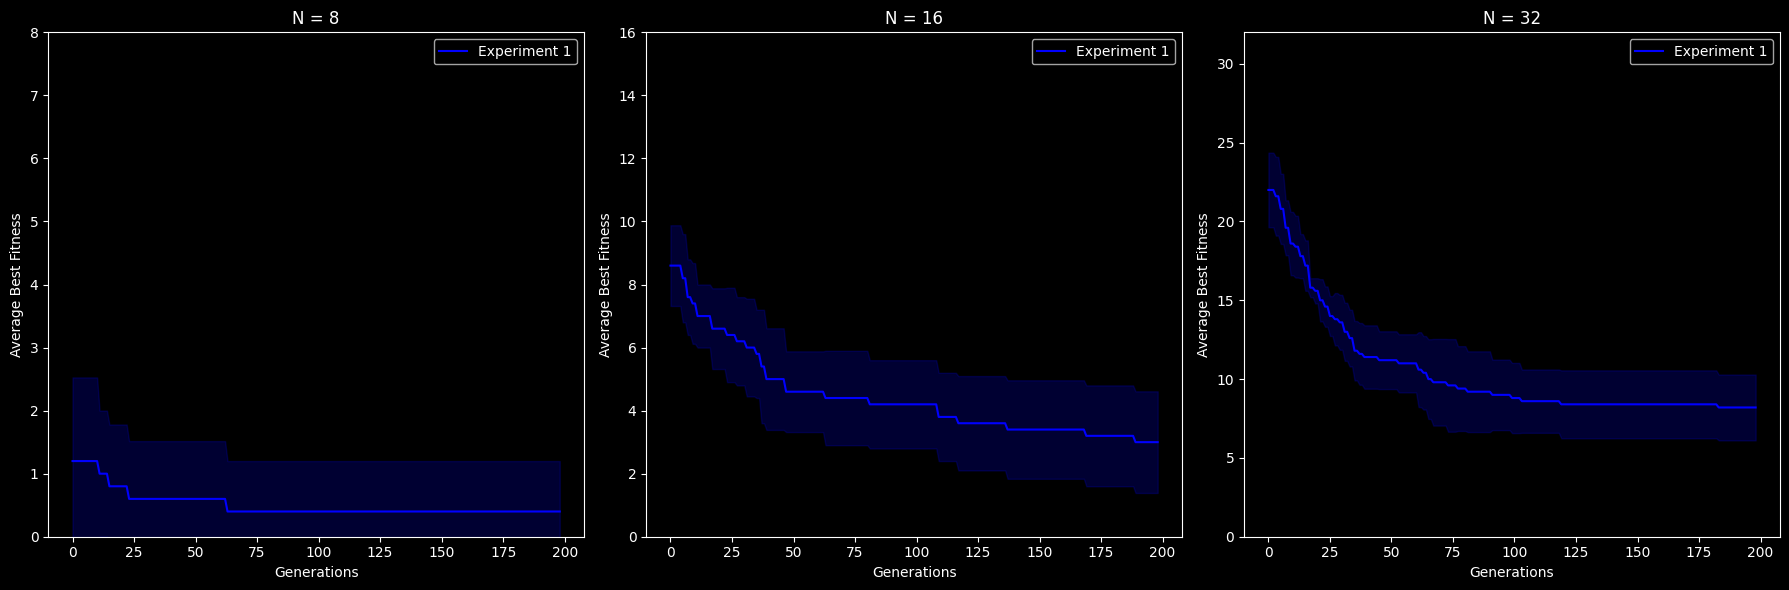

In [32]:
labels = ["N = 8", "N = 16", "N = 32"]

generate_subplot_function(
    avgs_experiment_1,
    stds_experiment_1,
    labels,
    avgs_experiment_2=None,
    stds_experiment_2=None,
    n_columns=3,
    n_queens=[8, 16, 32],
)

**Question 2.5 (0-0.2-0.4 pt)** Describe the average performance of the algorithm. What was the maximum average fitness found for each case? Do you see any differences between the problem cases?

**Answer**: AVERAGES: N=8 - 2 N=16 - 4 N=32 - 8

